# Load traced annotations for adult fly muscles in CT scan
CT-scan of adult fly from Dinges & Blanke, synchrotron microCT, pixel size around 667 nm
    Link to neuroglancer: https://spelunker.cave-explorer.org/#!middleauth+https://global.daf-apis.com/nglstate/api/v1/4626763617402880
    
Tracing done on Neuroglancer by Jasper and Gizem.
Muscles traced for Front Left leg, Middle Right leg, and Hind Left leg. Also some flight muscles.
Each muscle fiber traced as one line (two points), grouped by muscles.

### Json file structure
Json files saved directly from Neuroglancer. 
Structured as a dictionary - relevant elements below:
- [layers][0] : CT-scan images
- [layers][1] : segmentation meshes?
- [layers][2:] : Annotations
    - ...[name] : name of the specific annotation (ex. "LF ThCo 1")
    - ...[annotations] : each one is a line (two points)
        - ...[pointA] : start point
        - ...[pointB] : end point
            - ...[0,1,2] : xyz coordinates


In [226]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import matplotlib.colors as mcolors
import pickle



In [227]:
main_path = '/mnt/labserver/data/MA/Development_project/'
json_folder = os.path.join(main_path, 'CT_Adult_muscles')
json_file = os.path.join(json_folder, 'CT_adult_muscles.json')


In [228]:
# LOAD COORDINATES
coordinates = {}

json_path =  os.path.join(json_folder, json_file)

# Load json file
with open (json_path, 'r') as f:
    json_data = json.load(f)
    for annotation in json_data['layers'][2:]:
        name = annotation['name']
        exclude = ['nerve', 'joint', 'wing', 'proboscis', 'neck', 'tergotrochanter']
        if any(ex in name.lower() for ex in exclude):
            print(f"Skipping {name}")
        else:
            coordinates[name] = []
            for line in annotation['annotations']:
                pointA = np.array(line['pointA'])
                pointB = np.array(line['pointB'])
                coordinates[name].append(np.stack([pointA, pointB]).reshape(2, -1))

# join the 'are these weird...' fibers into their matching muscle names
coordinates['LH TiTa 3 (detached origin)'] += coordinates.pop('are these weird LH TiTa 3 fibers?')
coordinates['LH TiCl ltm1'] += coordinates.pop('are these weird LH ltm1 fibers?')

names = list(coordinates.keys())
names.sort()
print('')

for key in names:
    # add spaces after key names to align the print output
    print(key + " " * (40 - len(key)), end="")
    print(f": {len(coordinates[key])} fibers")

Skipping crazy proboscis muscle
Skipping L wing DLM
Skipping R wing DLM
Skipping L wing DVM
Skipping neck/ThCo? muscle 1
Skipping neck/ThCo? muscle 2 (different from 1?)
Skipping LF leg nerve
Skipping LF ThCo ball joint
Skipping R wing DVM
Skipping LF ThTr tergotrochanter
Skipping RM tergotrochanter
Skipping LH tergotrochanter

LF CoTr acc extensor?                   : 4 fibers
LF CoTr acc flexor?                     : 9 fibers
LF CoTr extensor?                       : 26 fibers
LF CoTr flexor?                         : 37 fibers
LF FeTa ltm2                            : 5 fibers
LF FeTi extensor                        : 33 fibers
LF FeTi flexor                          : 29 fibers
LF FeTi lateral acc flexor              : 14 fibers
LF FeTi medial acc flexor               : 13 fibers
LF ThCo 1                               : 4 fibers
LF ThCo 3 (same muscle as 1?)           : 6 fibers
LF ThCo 4                               : 28 fibers
LF ThCo 5                               : 18 fibers

In [229]:
# convert lines to points
coordinates_points = {}
for muscle in coordinates.keys():
    coordinates_points[muscle] = np.concatenate(coordinates[muscle], axis=0)

In [230]:
def plot_muscle(muscle_names, xyz=[0,2], color=None, newFig=True):

    if muscle_names == 'all':
        muscle_names = list(coordinates.keys())

    if newFig:
        plt.figure(figsize=(10, 10))    

    for idx, muscle_name in enumerate(muscle_names):
        if muscle_name not in coordinates:
            print(f"Muscle {muscle_name} not found in coordinates")
            return
        
        if color == None:
            c = list(mcolors.TABLEAU_COLORS.values())[idx % len(mcolors.TABLEAU_COLORS)]  
        else:  
            c = color    
        
        muscle_coords = coordinates[muscle_name]
        
        # Plot the muscle coordinates
        for line in muscle_coords:
             plt.plot(line[:, xyz[0]], line[:, xyz[1]], color=c)

    xyz_names = ['X', 'Y', 'Z']
    plt.xlabel(xyz_names[xyz[0]])
    plt.ylabel(xyz_names[xyz[1]])
    # flip all axes
    if newFig:
        plt.gca().invert_yaxis()
        plt.gca().invert_xaxis()
    plt.axis('equal')

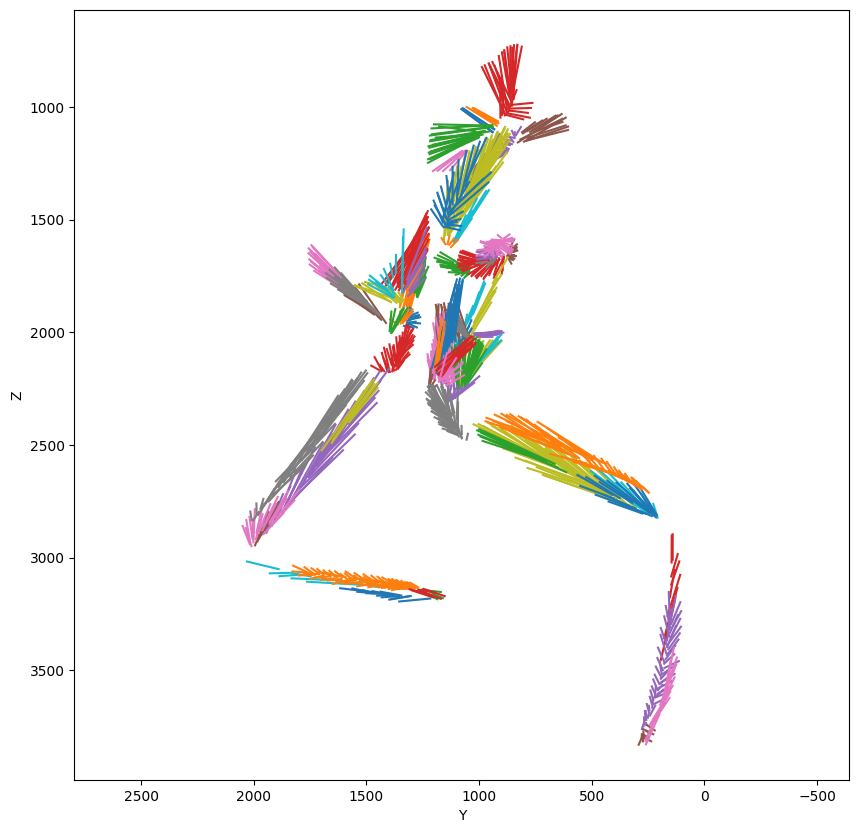

In [231]:
plot_muscle('all', xyz=[1,2])

In [232]:
import matplotlib.colors as mcolors

def adjust_color(color, amount=0.0):
    r, g, b = mcolors.to_rgb(color)

    if amount > 0:  # lighten toward white
        r = r + (1 - r) * amount
        g = g + (1 - g) * amount
        b = b + (1 - b) * amount
    elif amount < 0:  # darken toward black
        r = r * (1 + amount)
        g = g * (1 + amount)
        b = b * (1 + amount)

    return (r, g, b)

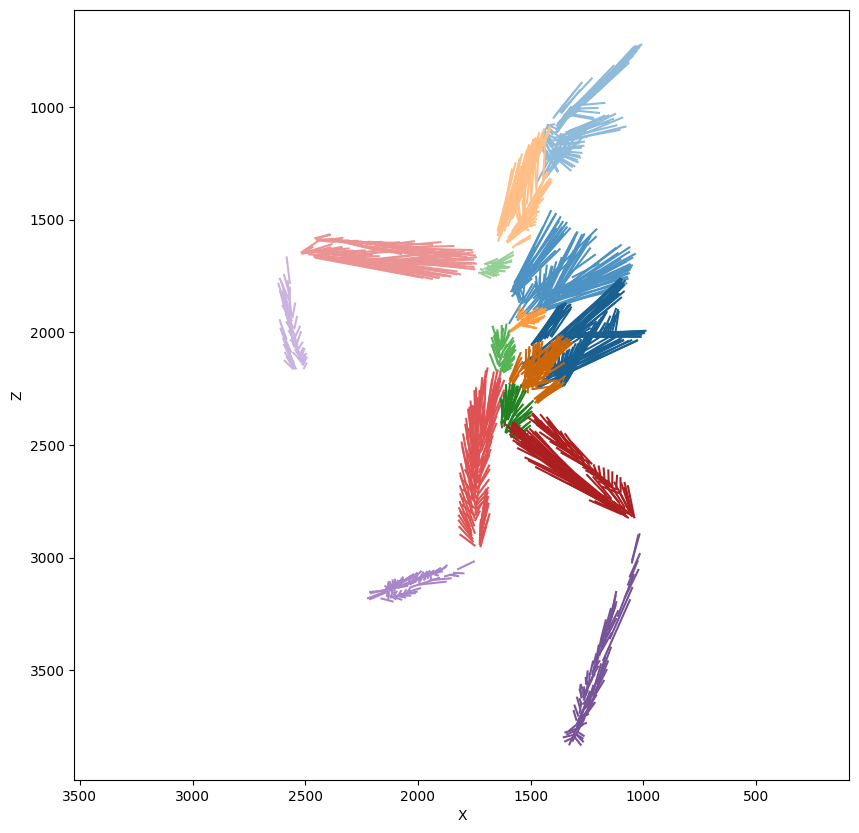

In [233]:
legs = ['LF', 'RM', 'LH']
segments = ['Th', 'Co', 'Tr', 'Fe', 'Ti']
segment_names = [leg + '_' + segment for leg in legs for segment in segments]
SEGMENT_GROUPS = {}
for segment in segment_names:
    SEGMENT_GROUPS[segment] = [muscle for muscle in names if muscle.startswith(segment.replace('_', ' '))]


# check that all muscles are categorized into segments
remaining_muscles = [muscle for muscle in names if muscle not in sum(SEGMENT_GROUPS.values(), [])]
assert len(remaining_muscles) == 0, f"Some muscles were not categorized: {remaining_muscles}"

# plot to check
plt.figure(figsize=(10, 10))
for idx, segment in enumerate(SEGMENT_GROUPS.keys()):
    c = list(mcolors.TABLEAU_COLORS.values())[idx % len(segments)] # set color based on segment
    a = [0.5, 0.2, -0.2][idx // len(segments)]  # set ligher color based on leg
    c = adjust_color(c, amount=a)  # lighten color based on leg
    plot_muscle(SEGMENT_GROUPS[segment], color=c, newFig=False)

plt.gca().invert_yaxis()
plt.gca().invert_xaxis()


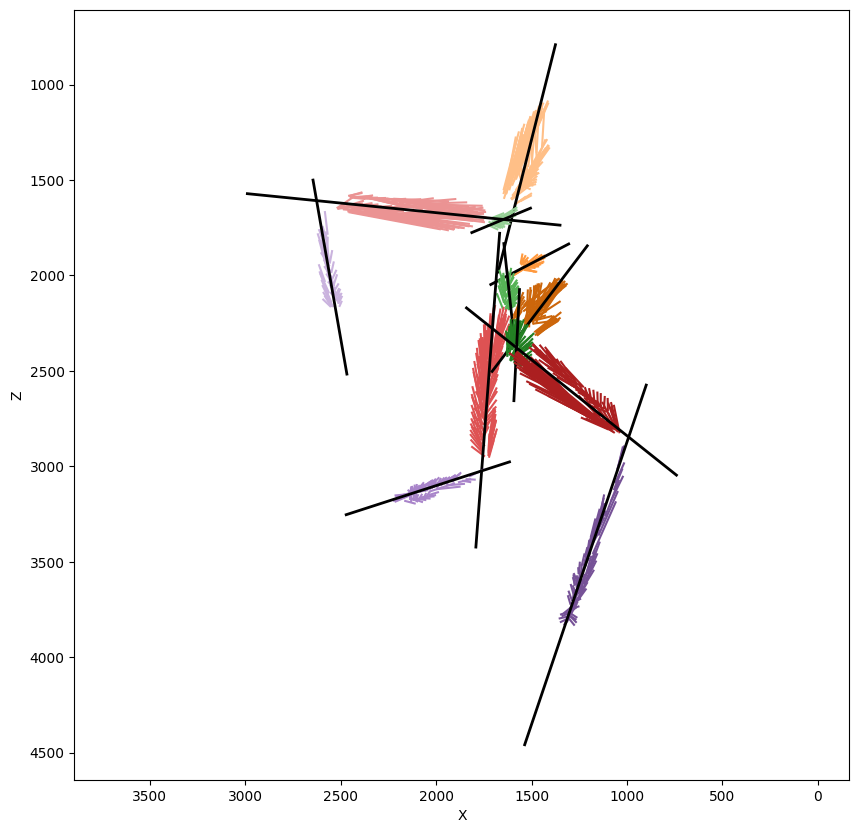

In [234]:
# For each segment (except Th), find the main axis (longest)
main_axes = {}
plt.figure(figsize=(10, 10))

for idx, segment in enumerate(SEGMENT_GROUPS.keys()):
    if 'Th' in segment:
        continue

    muscle_coords = []
    for muscle in SEGMENT_GROUPS[segment]:
        muscle_coords += coordinates[muscle]

    # concatenate all coordinates into a single array
    muscle_coords = np.concatenate(muscle_coords, axis=0)

    # find the longest axis using PCA
    pca = PCA(n_components=3)
    pca.fit(muscle_coords)
    main_axis = pca.components_[0]
    main_axes[segment] = main_axis

    # get color
    c = list(mcolors.TABLEAU_COLORS.values())[idx % len(segments)]  # set color based on segment
    a = [0.5, 0.2, -0.2][idx // len(segments)]  # set lighter color based on leg
    c = adjust_color(c, amount=a)

    # plot muscle
    plot_muscle(SEGMENT_GROUPS[segment], color=c, newFig=False)

    # ---- plot PCA main axis ----
    center = muscle_coords.mean(axis=0)
    direction = main_axes[segment]

    # length scale based on muscle size
    L = np.linalg.norm(np.ptp(muscle_coords, axis=0))

    p1 = center - direction * L
    p2 = center + direction * L

    # plot in x–z plane (matching your earlier indexing)
    plt.plot([p1[0], p2[0]], [p1[2], p2[2]], 'k', linewidth=2)

plt.gca().invert_yaxis()
plt.gca().invert_xaxis()
        

In [235]:
import numpy as np
import matplotlib.pyplot as plt
import shapely.geometry as geom
import shapely.ops as ops
from scipy.spatial import Delaunay

def alpha_shape(points, alpha):
    tri = Delaunay(points)
    edges = set()

    def add_edge(i, j):
        if (i, j) in edges or (j, i) in edges:
            edges.discard((j, i))
        else:
            edges.add((i, j))

    for ia, ib, ic in tri.simplices:
        pa, pb, pc = points[[ia, ib, ic]]
        a = np.linalg.norm(pb - pc)
        b = np.linalg.norm(pa - pc)
        c = np.linalg.norm(pa - pb)
        s = (a + b + c) / 2.0
        area = np.sqrt(max(s*(s-a)*(s-b)*(s-c), 0))
        if area == 0:
            continue
        circum_r = a*b*c / (4.0*area)
        if circum_r < 1.0 / alpha:
            add_edge(ia, ib)
            add_edge(ib, ic)
            add_edge(ic, ia)

    edge_points = [(points[i], points[j]) for i, j in edges]
    m = geom.MultiLineString(edge_points)
    return ops.polygonize(m)


In [236]:
# function to plot OUTLINE of each point-cloud
from matplotlib import legend


def plot_outline(coordinates, segments_plot, xyz_pair=[0,2], alpha=None, output=False, legend=False):
    if alpha is None:
        alpha = 0.00001  # smaller = tighter boundary

    outlines = {}
    
    # ensure plot_what is a list
    if isinstance(segments_plot, str):
        segments_plot = [segments_plot]

    for segment in segments_plot:
        for muscle in SEGMENT_GROUPS[segment]:

            x = coordinates[muscle][:,xyz_pair[0]]
            y = coordinates[muscle][:,xyz_pair[1]]

            points_2d = np.column_stack((x, y))
            polys = list(alpha_shape(points_2d, alpha))
            if len(polys) > 1:
                print(f"Warning: multiple polygons found for {muscle} in plane {xyz_pair}")

            for poly in polys:
                xs, ys = poly.exterior.xy
                plt.plot(xs, ys, label=muscle, linewidth=2)

        
    plt.xlabel(['X','Y','Z'][xyz_pair[0]])
    plt.ylabel(['X','Y','Z'][xyz_pair[1]])
    plt.gca().set_aspect('equal')
    if legend:
        # legend with multiple columns
        plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=4)

    if output:
        return outlines

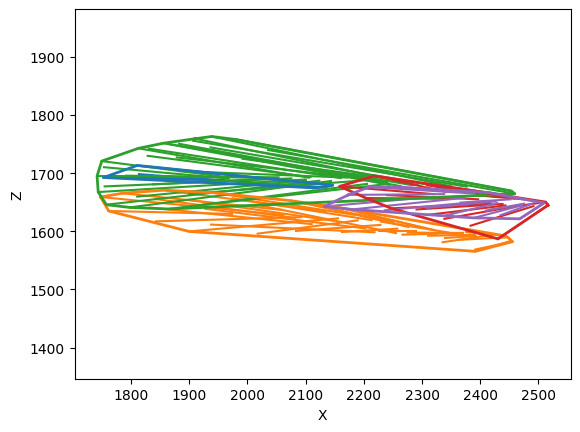

In [237]:
plot_muscle(SEGMENT_GROUPS['LF_Fe'], newFig=False)
plot_outline(coordinates_points, ['LF_Fe'])

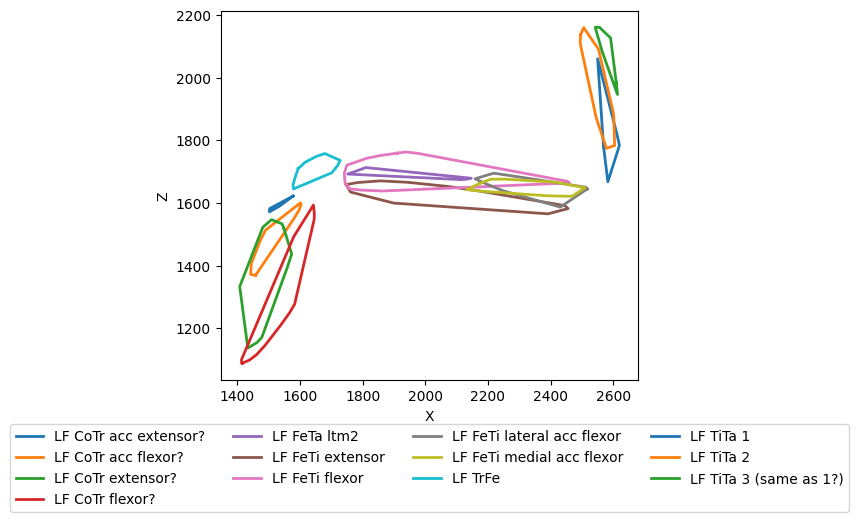

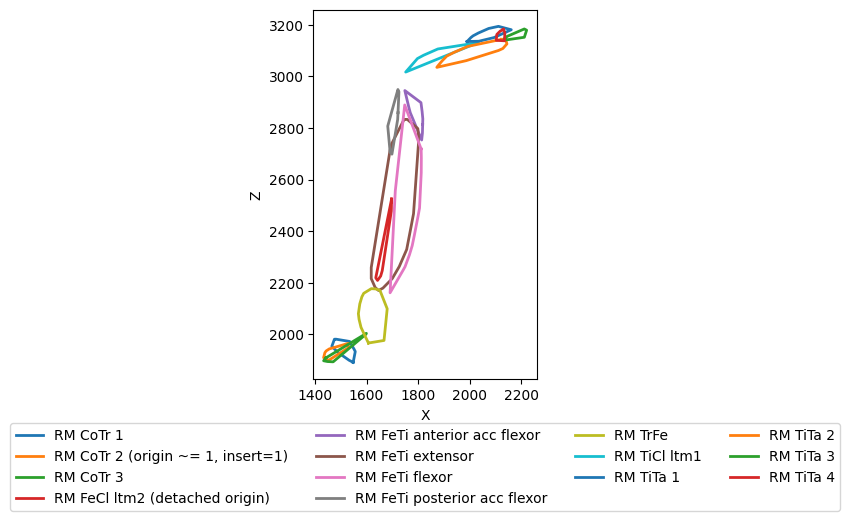

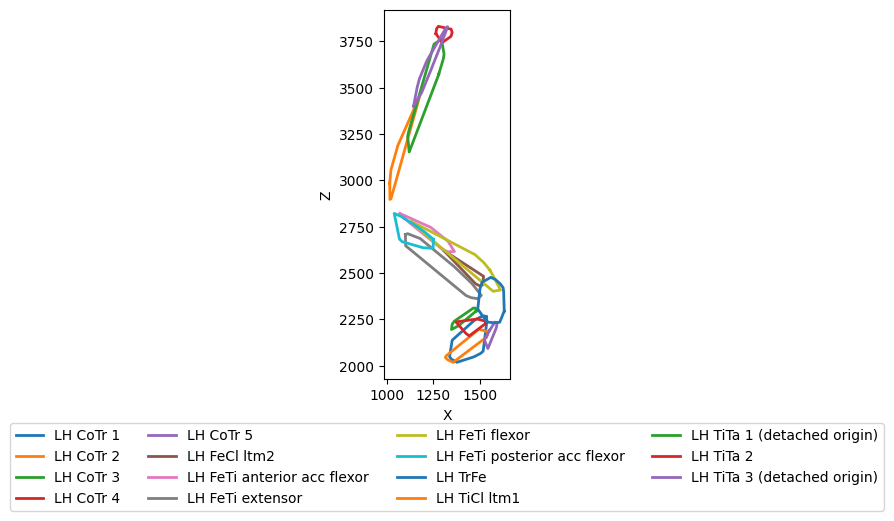

In [238]:
plot_outline(coordinates_points, ['LF_Co'], legend=True)
plot_outline(coordinates_points, ['LF_Fe'], legend=True)
plot_outline(coordinates_points, ['LF_Tr'], legend=True)
plot_outline(coordinates_points, ['LF_Ti'], legend=True)
plt.show()

plot_outline(coordinates_points, ['RM_Co'], legend=True)
plot_outline(coordinates_points, ['RM_Fe'], legend=True)
plot_outline(coordinates_points, ['RM_Tr'], legend=True)
plot_outline(coordinates_points, ['RM_Ti'], legend=True)
plt.show()

plot_outline(coordinates_points, ['LH_Co'], legend=True)
plot_outline(coordinates_points, ['LH_Fe'], legend=True)
plot_outline(coordinates_points, ['LH_Tr'], legend=True)
plot_outline(coordinates_points, ['LH_Ti'], legend=True)
plt.show()


In [239]:
350+1750

2100

In [281]:
# rotate each segment's coordinates to align with main axis and plot
coordinates_rotated = {}

# add an amount in x direction based on segment to prevent overlap after rotation
add_x = {'LF_Co': 350, 'LF_Tr': 750, 'LF_Fe': 1400, 'LF_Ti': 2200,
         'RM_Co': 100, 'RM_Tr': 400, 'RM_Fe': 1150, 'RM_Ti': 2250,
         'LH_Co': 350, 'LH_Tr': 750, 'LH_Fe': 1550, 'LH_Ti': 2750}  

rotate_X = ['RM_Ti', 'LH_Fe']

roll = {'LF_Fe':220}

for segment in SEGMENT_GROUPS.keys():
    if 'Th' in segment:
        continue

    # get main axis
    main_axis = main_axes[segment]

    # compute rotation matrix to align main axis with x-axis
    x_axis = np.array([1, 0, 0])
    v = np.cross(main_axis, x_axis)
    s = np.linalg.norm(v)
    c = np.dot(main_axis, x_axis)
    if s == 0:  # already aligned
        R = np.eye(3)
    else:
        vx = np.array([[0, -v[2], v[1]], [v[2], 0, -v[0]], [-v[1], v[0], 0]])
        R = np.eye(3) + vx + vx @ vx * ((1 - c) / (s ** 2))


    # get overall segment center
    segment_coords = []
    for muscle in SEGMENT_GROUPS[segment]:
        segment_coords.append(coordinates_points[muscle])
    segment_coords = np.concatenate(segment_coords, axis=0)
    segment_center = segment_coords.mean(axis=0)

    # rotate coordinates
    for muscle in SEGMENT_GROUPS[segment]:
        coords_centered = coordinates_points[muscle] - segment_center

        # rotate
        coords_rot = coords_centered @ R.T

        # if segment in rotate_X, rotate 180 degrees around z axis
        if segment in rotate_X:
            coords_rot[:, 0] = -coords_rot[:, 0]

        # add an amount in x direction to prevent overlap after rotation
        coords_rot[:, 0] += add_x[segment]

        # roll muscles along the X axis based on the roll dict
        if segment in roll:
            angle = np.radians(roll[segment])
            cos_angle = np.cos(angle)
            sin_angle = np.sin(angle)
            y_new = coords_rot[:, 1] * cos_angle - coords_rot[:, 2] * sin_angle
            z_new = coords_rot[:, 1] * sin_angle + coords_rot[:, 2] * cos_angle
            coords_rot[:, 1] = y_new
            coords_rot[:, 2] = z_new

        # save
        coordinates_rotated[muscle] = coords_rot


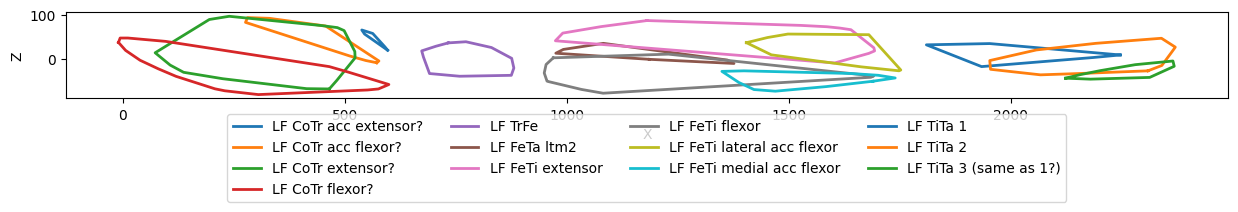

In [282]:
plt.figure(figsize=(15, 10))
plot_outline(coordinates_rotated, ['LF_Co'], legend=True)
plot_outline(coordinates_rotated, ['LF_Tr'], legend=True)
plot_outline(coordinates_rotated, ['LF_Fe'], legend=True)
plot_outline(coordinates_rotated, ['LF_Ti'], legend=True)
plt.show()

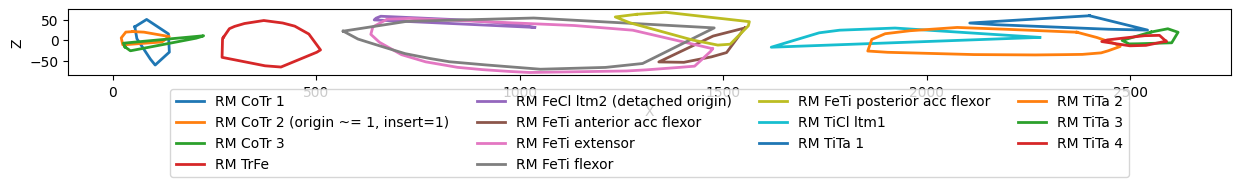

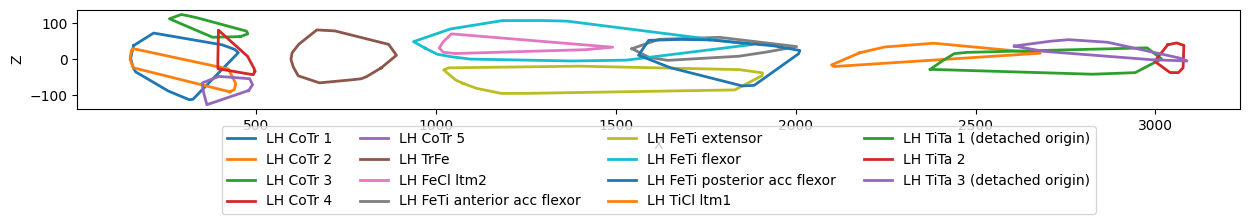

In [268]:

plt.figure(figsize=(15, 10))
plot_outline(coordinates_rotated, ['RM_Co'], legend=True)
plot_outline(coordinates_rotated, ['RM_Tr'], legend=True)
plot_outline(coordinates_rotated, ['RM_Fe'], legend=True)
plot_outline(coordinates_rotated, ['RM_Ti'], legend=True)
plt.show()

plt.figure(figsize=(15, 10))
plot_outline(coordinates_rotated, ['LH_Co'], legend=True)
plot_outline(coordinates_rotated, ['LH_Tr'], legend=True)
plot_outline(coordinates_rotated, ['LH_Fe'], legend=True)
plot_outline(coordinates_rotated, ['LH_Ti'], legend=True)
plt.show()